In [17]:
import sys, os
sys.path.append(os.path.abspath('..'))

import torch
import torchvision
from ultralytics import YOLO
from torchvision.models.detection import _utils
from torchvision.models.detection.ssd import SSDClassificationHead
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import DataLoader

from CustomDataset import CustomDataset
import albumentations as A

from proposal_codes.utils import show_img_with_boxes, to_device



# Load models

In [ ]:
# Load SSD

num_class = 4
ssd_model = torchvision.models.detection.ssd300_vgg16()

in_channels = _utils.retrieve_out_channels(ssd_model.backbone, (300, 300))
num_anchors = ssd_model.anchor_generator.num_anchors_per_location()

# Replace the classification head for 4 classes + background
ssd_model.head.classification_head = SSDClassificationHead(
    in_channels=in_channels,
    num_anchors=num_anchors,
    num_classes=num_class + 1
)

# Adjust transform sizes
ssd_model.transform.min_size = (300,)
ssd_model.transform.max_size = 300


In [ ]:
ssd_state_dict = torch.load("./SSD_mobile_detection.pth", weights_only=True)
ssd_model.load_state_dict(ssd_state_dict)

for param in ssd_model.parameters():
    param.requires_grad = False


print(ssd_model)

SSD(
  (backbone): SSDFeatureExtractorVGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=

In [ ]:
#load RCNN 
RCNN_model = fasterrcnn_resnet50_fpn_v2(
    progress=True,
    trainable_backbone_layers = 1
    )

# Replace the classification head
in_features = RCNN_model.roi_heads.box_predictor.cls_score.in_features
RCNN_model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_class + 1)

rcnn_state_dict = torch.load("./fasterRCNN.pth", weights_only=True)
RCNN_model.load_state_dict(rcnn_state_dict)

print(RCNN_model)


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       

In [9]:
#Load Yolo
yolov11 = YOLO("./runs/detect/train4/weights/best.pt")

# Load dataset

In [26]:
test_transforms = A.Compose([
    A.RandomCrop(width=300, height=300, p=1.0),
    A.Normalize(),
    A.pytorch.ToTensorV2(),
],  bbox_params=A.BboxParams(format='pascal_voc', 
                        label_fields=["class_labels"],
                        clip=True,
                        min_visibility=0.1
                        ))

test_image_dir = "../data/incabinDetection/test/images"
test_label_dir = "../data/incabinDetection/test/labels"
test_labels = os.listdir(test_label_dir)

test_datset = CustomDataset(
    test_image_dir,
    test_labels,
    test_label_dir,
    transform=test_transforms)

test_loader = DataLoader(
    test_datset,
    shuffle=False,
    batch_size=4,
    collate_fn=lambda x: tuple(zip(*x)))

[ WARN:0@15350.263] global loadsave.cpp:275 findDecoder imread_('../data/incabinDetection/test/images/image593_png.rf.171724f0025ad0392679284f1284e355_aug_l2_000315.jpg'): can't open/read file: check file path/integrity
[ WARN:0@15350.267] global loadsave.cpp:275 findDecoder imread_('../data/incabinDetection/test/images/image3022_png.rf.8f992620440583fba2a04c20d517e535_aug_l3_000738.jpg'): can't open/read file: check file path/integrity
[ WARN:0@15350.267] global loadsave.cpp:275 findDecoder imread_('../data/incabinDetection/test/images/image484_png.rf.25e05d88aab05de0b35b45e87c28cf7d_aug_l2_000446.jpg'): can't open/read file: check file path/integrity
[ WARN:0@15350.267] global loadsave.cpp:275 findDecoder imread_('../data/incabinDetection/test/images/image2232_png.rf.d973e5b7435e42706692ea446c195701_aug_l3_000222.jpg'): can't open/read file: check file path/integrity
[ WARN:0@15350.267] global loadsave.cpp:275 findDecoder imread_('../data/incabinDetection/test/images/image2615_png.rf

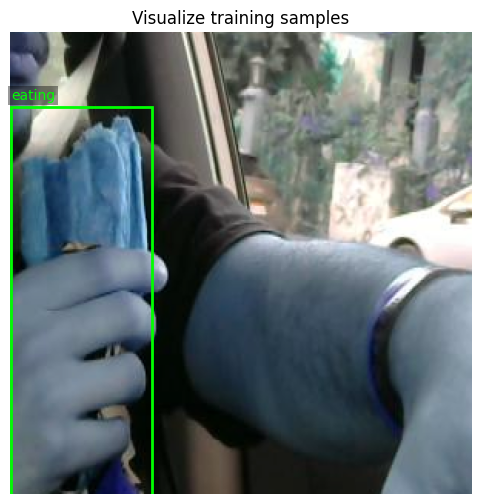

[ WARN:0@15350.392] global loadsave.cpp:275 findDecoder imread_('../data/incabinDetection/test/images/image2232_png.rf.d973e5b7435e42706692ea446c195701_aug_l3_000222.jpg'): can't open/read file: check file path/integrity
[ WARN:0@15350.393] global loadsave.cpp:275 findDecoder imread_('../data/incabinDetection/test/images/image2615_png.rf.c2c136c0515bc964f353704302594bbc_aug_l2_000171.jpg'): can't open/read file: check file path/integrity
[ WARN:0@15350.393] global loadsave.cpp:275 findDecoder imread_('../data/incabinDetection/test/images/image362_png.rf.a4eb563c0e776dd39e06f5480e6a9a74_aug_l2_000214.jpg'): can't open/read file: check file path/integrity
[ WARN:0@15350.393] global loadsave.cpp:275 findDecoder imread_('../data/incabinDetection/test/images/image1598_png.rf.7ee5c5ad33fa94bb03b070685e9cc6da_aug_l2_000382.jpg'): can't open/read file: check file path/integrity
[ WARN:0@15350.393] global loadsave.cpp:275 findDecoder imread_('../data/incabinDetection/test/images/image752_png.rf

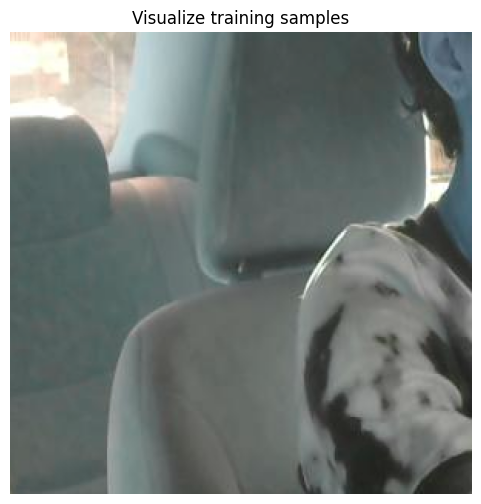

In [27]:
sample_iter = iter(test_loader)

label_names = {
    1:'drinking',
    2:'eating',
    3: 'mobile use',
    4: 'smoking'}

for _ in range(2):
    sample = next(sample_iter)
    img, target = sample
    show_img_with_boxes(img[0], target[0], label_names=label_names, title="Visualize training samples")
